<a href="https://colab.research.google.com/github/Dhanshree010/Machine-Vision-Practical/blob/main/practical2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files



In [2]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Saving images.jpg to images (1).jpg


In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# ==========================================================
# Step 3: Image Scaling
# ==========================================================
scaled = cv2.resize(img, None, fx=1.5, fy=1.5,
                    interpolation=cv2.INTER_LINEAR)

# ==========================================================
# Step 4: Image Rotation
# ==========================================================
(h, w) = img.shape[:2]

center = (w // 2, h // 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)

rotated = cv2.warpAffine(img, rotation_matrix, (w, h))

In [4]:
rows, cols = img.shape[:2]

pts1 = np.float32([[50, 50],
                   [200, 50],
                   [50, 200]])

pts2 = np.float32([[20, 100],
                   [200, 50],
                   [100, 250]])

affine_matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(img, affine_matrix, (cols, rows))

# ==========================================================
# Step 6: Thresholding
# ==========================================================
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

# ==========================================================
# Step 7: Find Contours
# ==========================================================
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

measurement = img.copy()

print("="*45)
print("        OBJECT MEASUREMENTS")
print("="*45)

count = 1

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 500:

        x, y, w, h = cv2.boundingRect(cnt)

        perimeter = cv2.arcLength(cnt, True)

        cv2.rectangle(
            measurement,
            (x, y),
            (x+w, y+h),
            (255, 0, 0),
            3
        )

        cv2.putText(
            measurement,
            f"{w}px x {h}px",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

        print(f"\nObject {count}")
        print("------------------------")
        print("Width      :", w, "pixels")
        print("Height     :", h, "pixels")
        print("Area       :", round(area,2), "pixels²")
        print("Perimeter  :", round(perimeter,2), "pixels")

        count += 1


        OBJECT MEASUREMENTS

Object 1
------------------------
Width      : 142 pixels
Height     : 110 pixels
Area       : 10991.0 pixels²
Perimeter  : 474.39 pixels

Object 2
------------------------
Width      : 43 pixels
Height     : 75 pixels
Area       : 626.0 pixels²
Perimeter  : 228.17 pixels

Object 3
------------------------
Width      : 91 pixels
Height     : 62 pixels
Area       : 882.5 pixels²
Perimeter  : 264.84 pixels


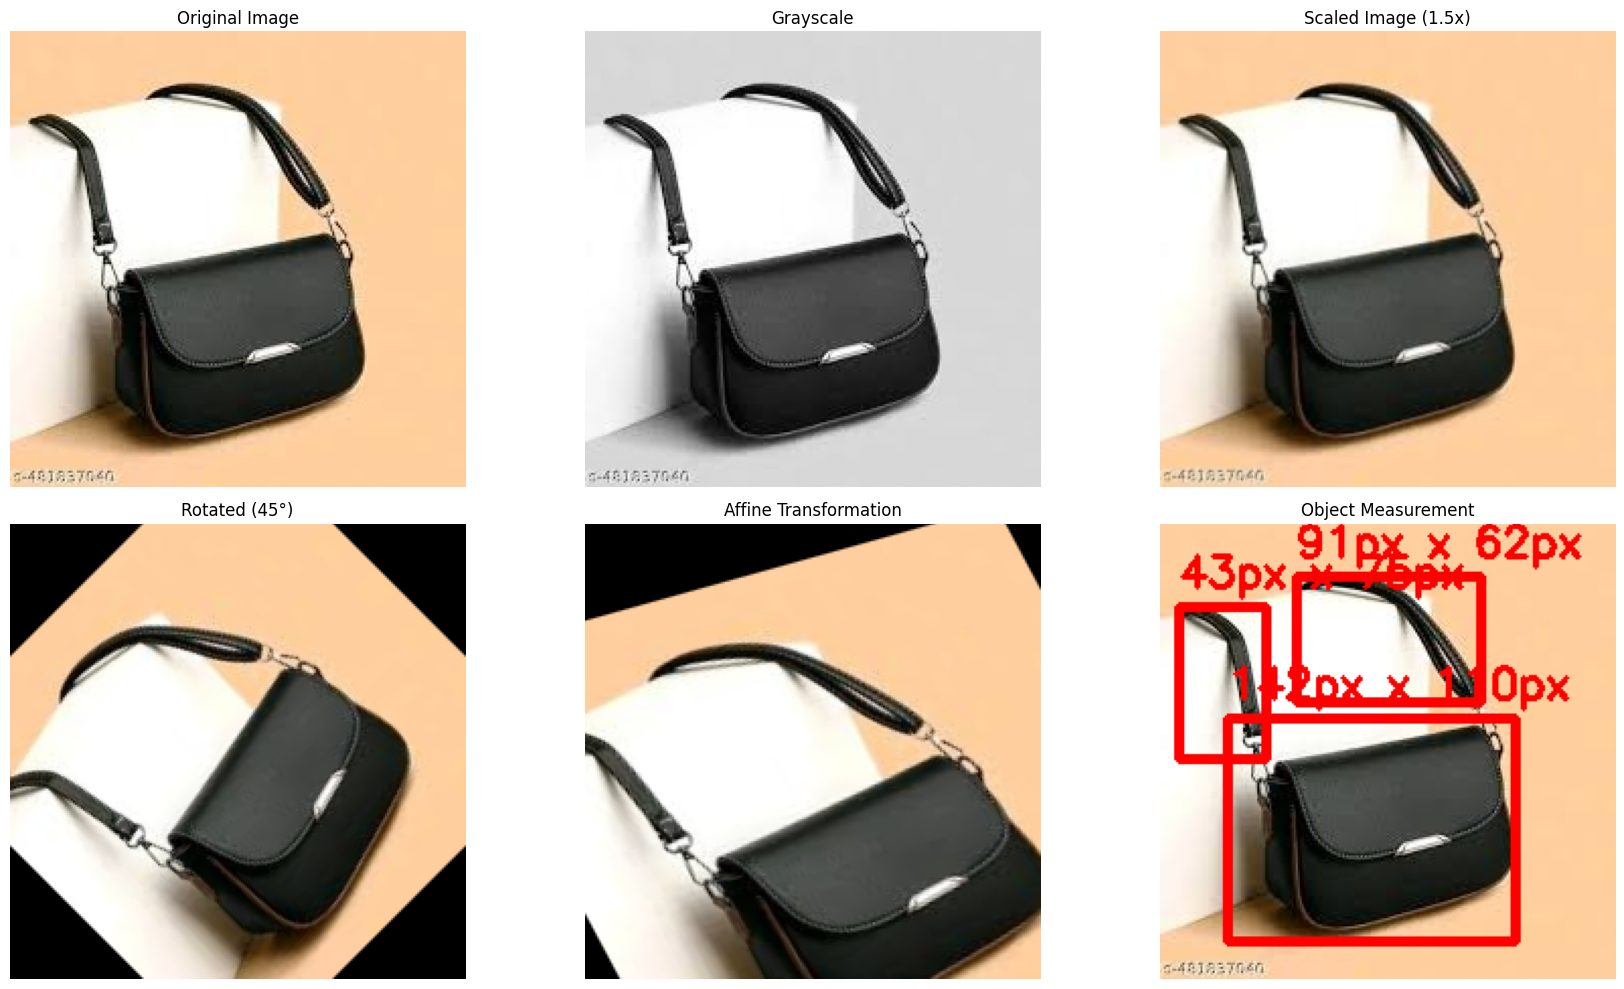

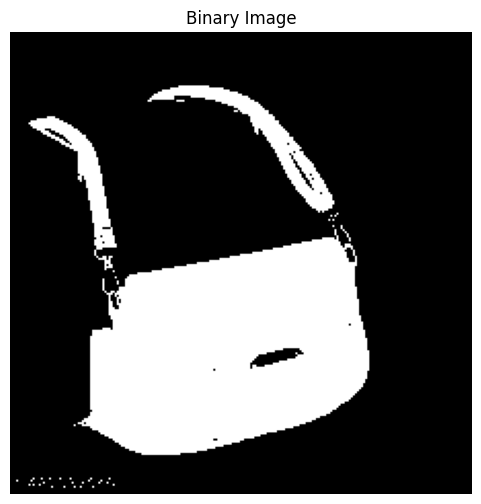

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0,0].imshow(img)
ax[0,0].set_title("Original Image")
ax[0,0].axis("off")

ax[0,1].imshow(gray, cmap="gray")
ax[0,1].set_title("Grayscale")
ax[0,1].axis("off")

ax[0,2].imshow(scaled)
ax[0,2].set_title("Scaled Image (1.5x)")
ax[0,2].axis("off")

ax[1,0].imshow(rotated)
ax[1,0].set_title("Rotated (45°)")
ax[1,0].axis("off")

ax[1,1].imshow(affine)
ax[1,1].set_title("Affine Transformation")
ax[1,1].axis("off")

ax[1,2].imshow(measurement)
ax[1,2].set_title("Object Measurement")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# Step 9: Display Binary Image
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Binary Image")
plt.axis("off")
plt.show()